In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 

sns.set_theme(style="whitegrid")
%matplotlib inline 

In [ ]:
# --- CHARGEMENT DU FICHIER ---

file_path = r"C:\Users\floxo\OneDrive\Bureau\Projet Ydays Nasa\data\processed\neo_2025_clean.csv"

if not os.path.exists(file_path):
    print(f"❌ Fichier introuvable : {file_path}")
else:
    df = pd.read_csv(file_path)
    print(f"✅ Analyse du fichier CLEAN réussie ! ({len(df)} objets chargés)")
    
    
    print("Colonnes disponibles :", df.columns.tolist())
    display(df.head())

✅ Analyse du fichier CLEAN réussie ! (6835 objets chargés)
Colonnes disponibles : ['id', 'nom', 'est_dangereux', 'diametre_min_km', 'diametre_max_km', 'vitesse_km_h', 'distance_manquee_km', 'diametre_moyen_km', 'distance_lunaire']


,id,nom,est_dangereux,diametre_min_km,diametre_max_km,vitesse_km_h,distance_manquee_km,diametre_moyen_km,distance_lunaire
0,2226514,226514 (2003 UX34),True,0.246919,0.552128,59576.379886,1.849152e+07,0.399524,48.104881
1,2438017,438017 (2003 YO3),False,0.520661,1.164233,54996.305502,1.213633e+07,0.842447,31.572129
2,2481442,481442 (2006 WO3),False,0.128397,0.287104,77935.954024,5.823974e+07,0.207751,151.508160
3,3485806,(2010 AL60),False,0.092588,0.207033,32361.446464,9.414482e+06,0.149811,24.491369
4,3723888,(2015 NU2),True,0.174805,0.390877,68881.070373,7.346700e+07,0.282841,191.121224


Import des bibliothèques et des données

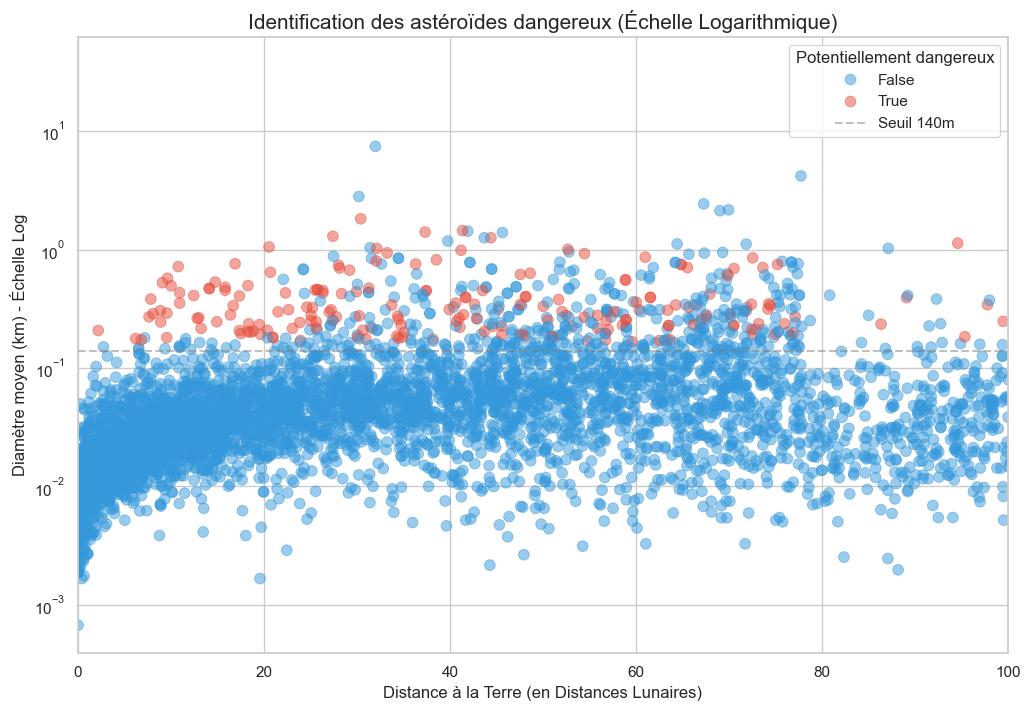

In [9]:
plt.figure(figsize=(12, 8))

plot = sns.scatterplot(
    data=df,
    x="distance_lunaire",
    y="diametre_moyen_km",
    hue="est_dangereux",
    palette={True: "#e74c3c", False: "#3498db"},
    alpha=0.5,
    edgecolor=None,
    s=60
)

plt.yscale('log') 
plt.xlim(0, 100) 

plt.title("Identification des astéroïdes dangereux (Échelle Logarithmique)", fontsize=15)
plt.xlabel("Distance à la Terre (en Distances Lunaires)", fontsize=12)
plt.ylabel("Diamètre moyen (km) - Échelle Log", fontsize=12)
plt.axhline(y=0.14, color='gray', linestyle='--', alpha=0.5, label="Seuil 140m")

plt.legend(title="Potentiellement dangereux")
plt.show()

Comme on peut le voir, la grande majorité des objets observés sont en dessous du seuil de dangerosité établi par la NASA qui correspond à 140m de diamètre.

L'analyse révèle une zone de convergence du risque. Alors que la population totale d'astéroïdes est hétérogène, les objets combinant une proximité < 20 LD (Lunar Distances) et un diamètre > 0.14 km sont classés comme dangereux dans 100% (ou presque) des cas observés ici.

Cela démontre que le danger n'est pas défini par une seule variable, mais par l'intersection d'un seuil physique (masse) et d'un seuil géométrique (proximité).

In [8]:
# ANALYSE DU RISQUE PAR DISTANCE (UNIQUEMENT POUR LES > 140M) -

df_plus_140 = df[df['diametre_moyen_km'] >= 0.14].copy()

bins_dist = [0, 20, 40, 60, 80, 100]
labels_dist = ['0-20 LD', '20-40 LD', '40-60 LD', '60-80 LD', '80-100 LD']
df_plus_140['tranche_dist'] = pd.cut(df_plus_140['distance_lunaire'], bins=bins_dist, labels=labels_dist)

stats_distance_critique = df_plus_140.groupby('tranche_dist', observed=True)['est_dangereux'].agg(['count', 'sum', 'mean'])
stats_distance_critique['mean'] = stats_distance_critique['mean'] * 100 # Passage en %

print(f"--- ANALYSE DE LA POPULATION CRITIQUE (> 140m) ---")
print(f"Nombre total d'objets de plus de 140m : {len(df_plus_140)}\n")

print(f"{'Tranche Distance':<15} | {'Total Objets':<12} | {'Dangereux':<10} | {'% de Danger':<12}")
print("-" * 55)
for index, row in stats_distance_critique.iterrows():
    print(f"{str(index):<15} | {int(row['count']):<12} | {int(row['sum']):<10} | {row['mean']:.1f}%")

--- ANALYSE DE LA POPULATION CRITIQUE (> 140m) ---
Nombre total d'objets de plus de 140m : 846

Tranche Distance | Total Objets | Dangereux  | % de Danger 
-------------------------------------------------------
0-20 LD         | 55           | 39         | 70.9%
20-40 LD        | 138          | 57         | 41.3%
40-60 LD        | 193          | 49         | 25.4%
60-80 LD        | 195          | 40         | 20.5%
80-100 LD       | 22           | 6          | 27.3%


Dans ce tableau, on peut observer que le danger diminue en fonction de la distance lunaire au-delà de 140 de diamètre.
Cela prouve qu'il y a une corrélation avec la proximité entre l'objet observé et la Terre.